<a href="https://colab.research.google.com/github/Govind-2004/Case_Study_Preprocessing/blob/main/assignment_14_07_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Reading Dataset

In [5]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Datasets /adult_dataset.csv'
adult_df = pd.read_csv(file_path)
adult_df.head(3)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K


In [6]:
adult_df['capital-gain'].value_counts()

,count
capital-gain,
0,44807
15024,513
7688,410
7298,364
99999,244
...,...
1639,1
2387,1
7262,1


# EDA

In [7]:
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [8]:
adult_df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [9]:
# checking duplicated values
adult_df.duplicated().sum()

np.int64(16)

In [10]:
# checking for missing values if any
adult_df.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [11]:
# splitting num_cols and cat_cols

num_cols = adult_df.select_dtypes(include=['int','float']).columns
cat_cols = adult_df.select_dtypes(include=['object']).columns

## Data Visualization

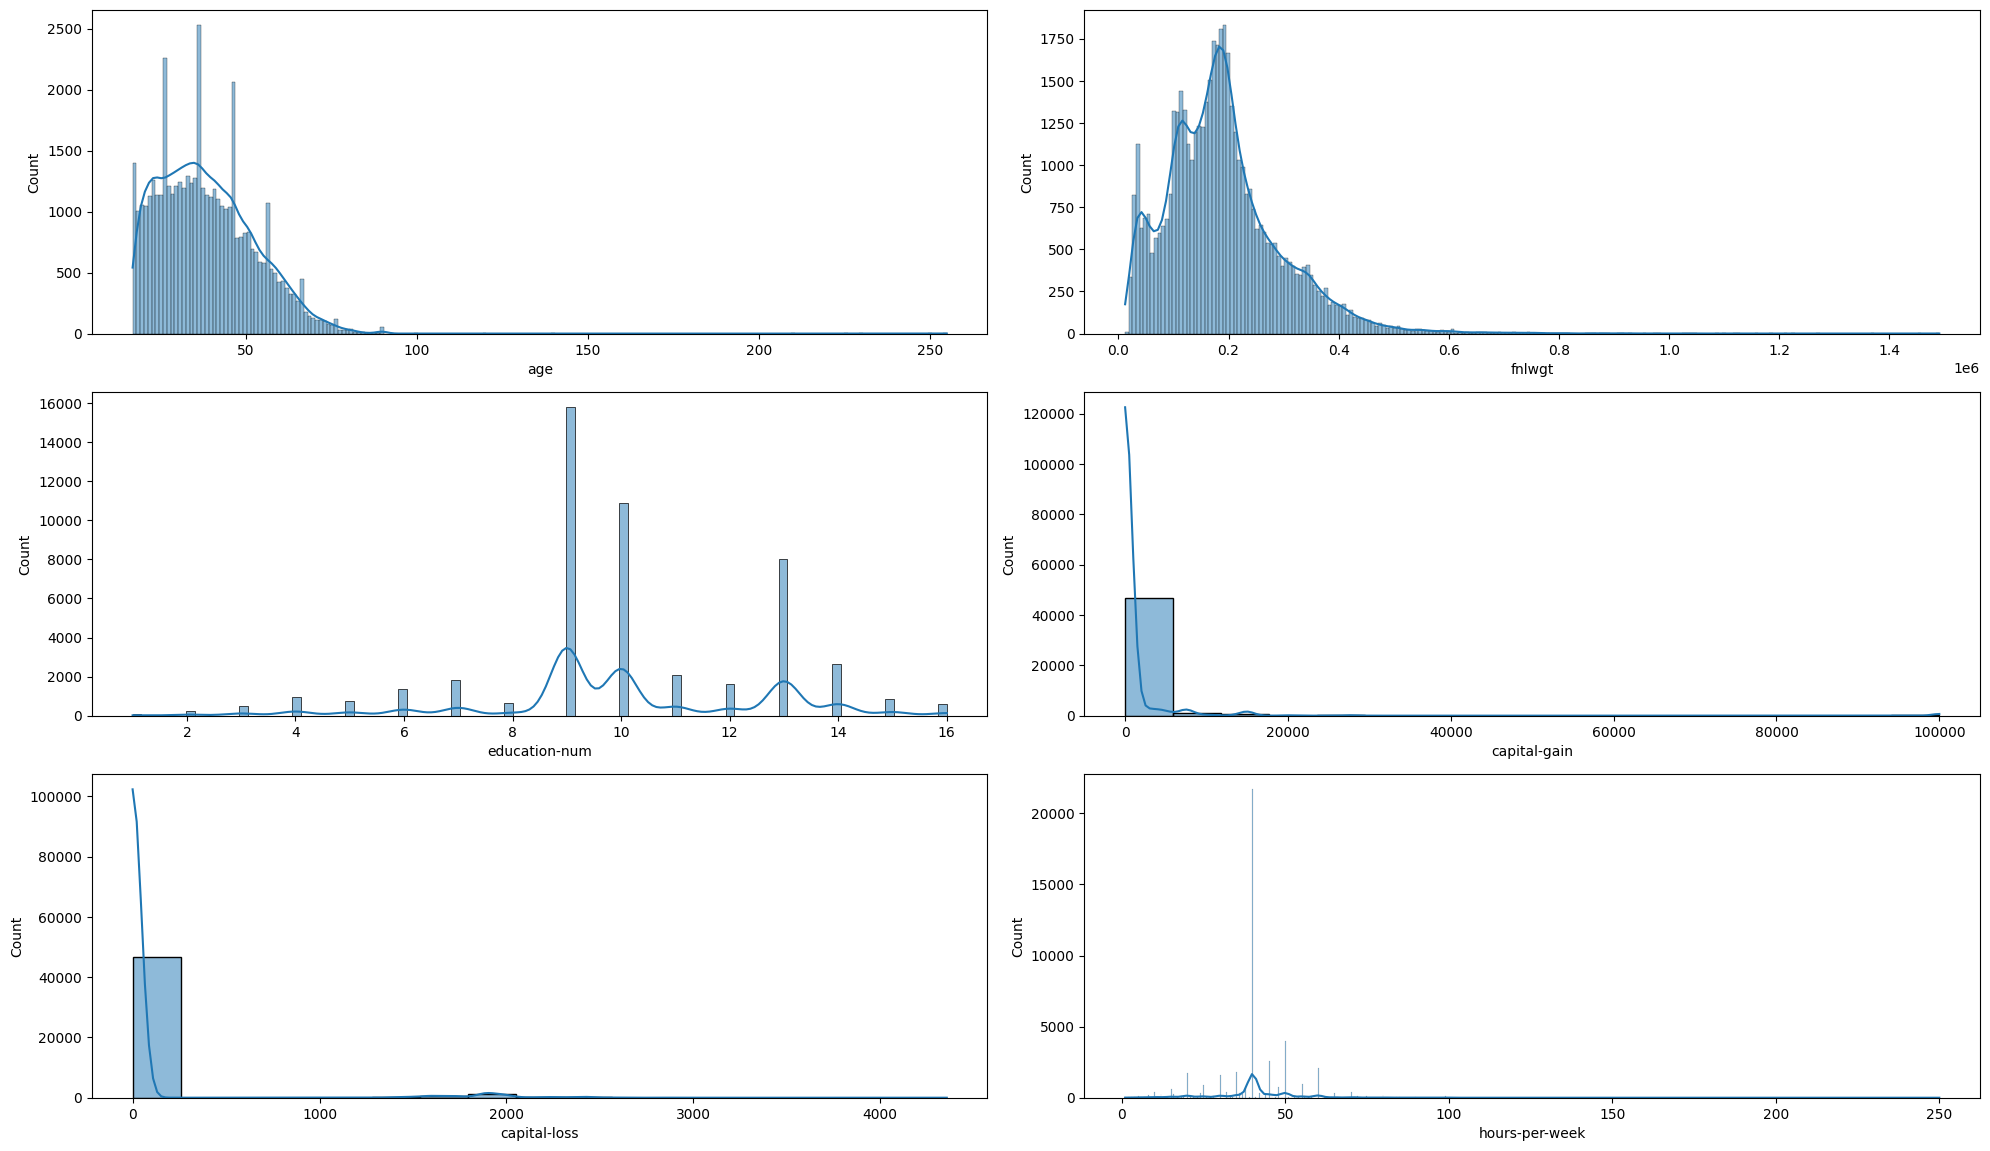

In [12]:
# plot histogram

plt.figure(figsize=(20,15))

for i,column in enumerate(num_cols):
  plt.subplot(4,2,i+1)
  sns.histplot(adult_df[column], kde=True)

plt.tight_layout()
plt.show()


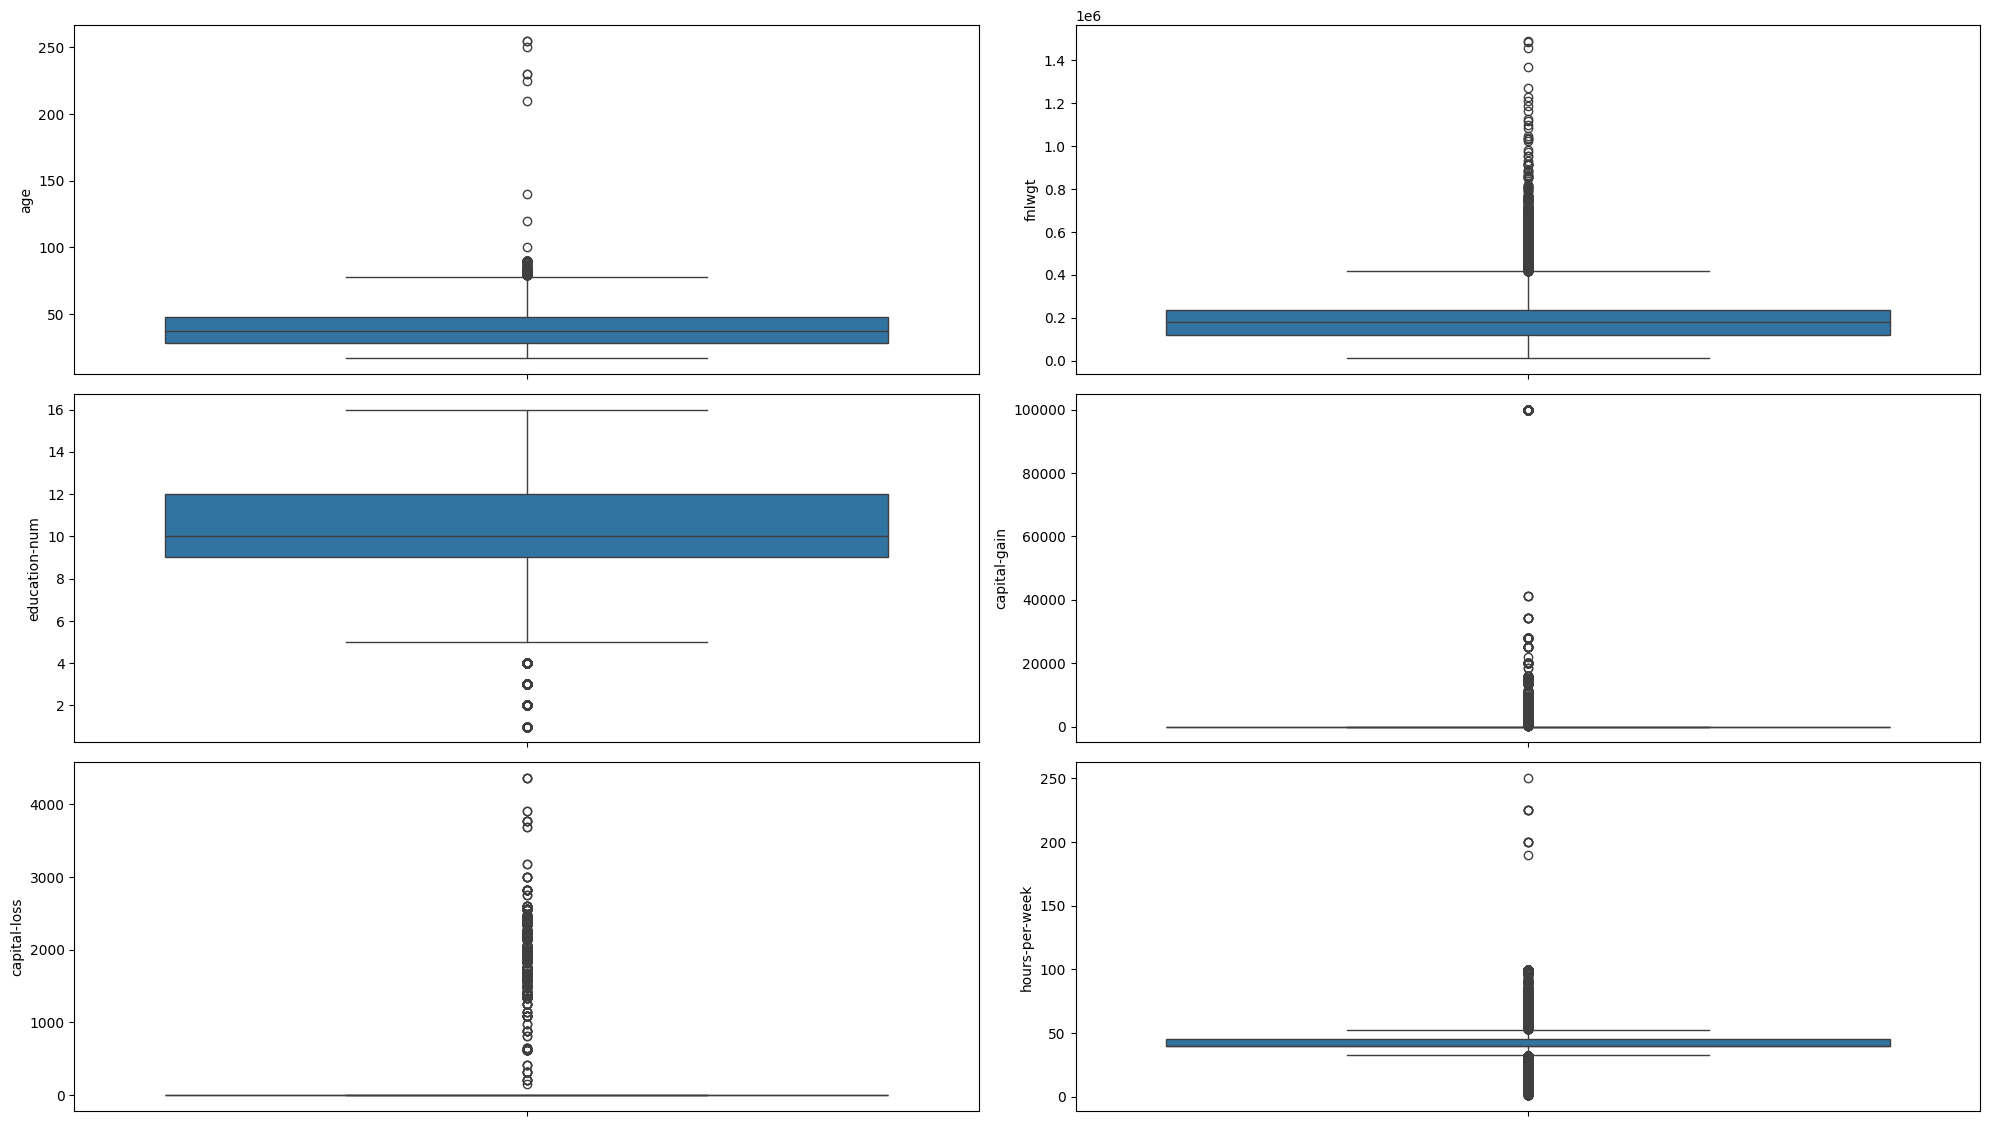

In [13]:
# for understanding about the outliers we plot boxplot

plt.figure(figsize=(20,15))

for i,column in enumerate(num_cols):
  plt.subplot(4,2,i+1)
  sns.boxplot(adult_df[column])

plt.tight_layout()
plt.show()


# Preprocessing

In [14]:
# droping Duplicated values :
adult_df.drop_duplicates(inplace=True)

In [15]:
# verifying if duplicated is present :
adult_df.duplicated().sum()

np.int64(0)

## Missing Value Handling

In [16]:
adult_df.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [17]:
for col in num_cols:
    if adult_df[col].isnull().any():
        median_val = adult_df[col].median()
        adult_df[col].fillna(median_val, inplace=True)


/tmp/ipykernel_398/3917028638.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_df[col].fillna(median_val, inplace=True)


In [18]:
for col in cat_cols:
    if (adult_df[col] == '?').any():
        adult_df[col].replace('?', np.nan, inplace=True)        # Replace '?' with NaN first

    if adult_df[col].isnull().any():
        mode_val = adult_df[col].mode()[0]
        adult_df[col].fillna(mode_val, inplace=True)


/tmp/ipykernel_398/4164134353.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_df[col].replace('?', np.nan, inplace=True)        # Replace '?' with NaN first
/tmp/ipykernel_398/4164134353.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].

In [19]:
# verify after handling values
adult_df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


## Outlier Handling

In [20]:
for col in num_cols:
    if col in ['capital-gain', 'capital-loss']:   # for skipping the columns related to finance
        continue

    Q1 = adult_df[col].quantile(0.25)
    Q3 = adult_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    adult_df[col] = np.clip(adult_df[col], lower_bound, upper_bound)

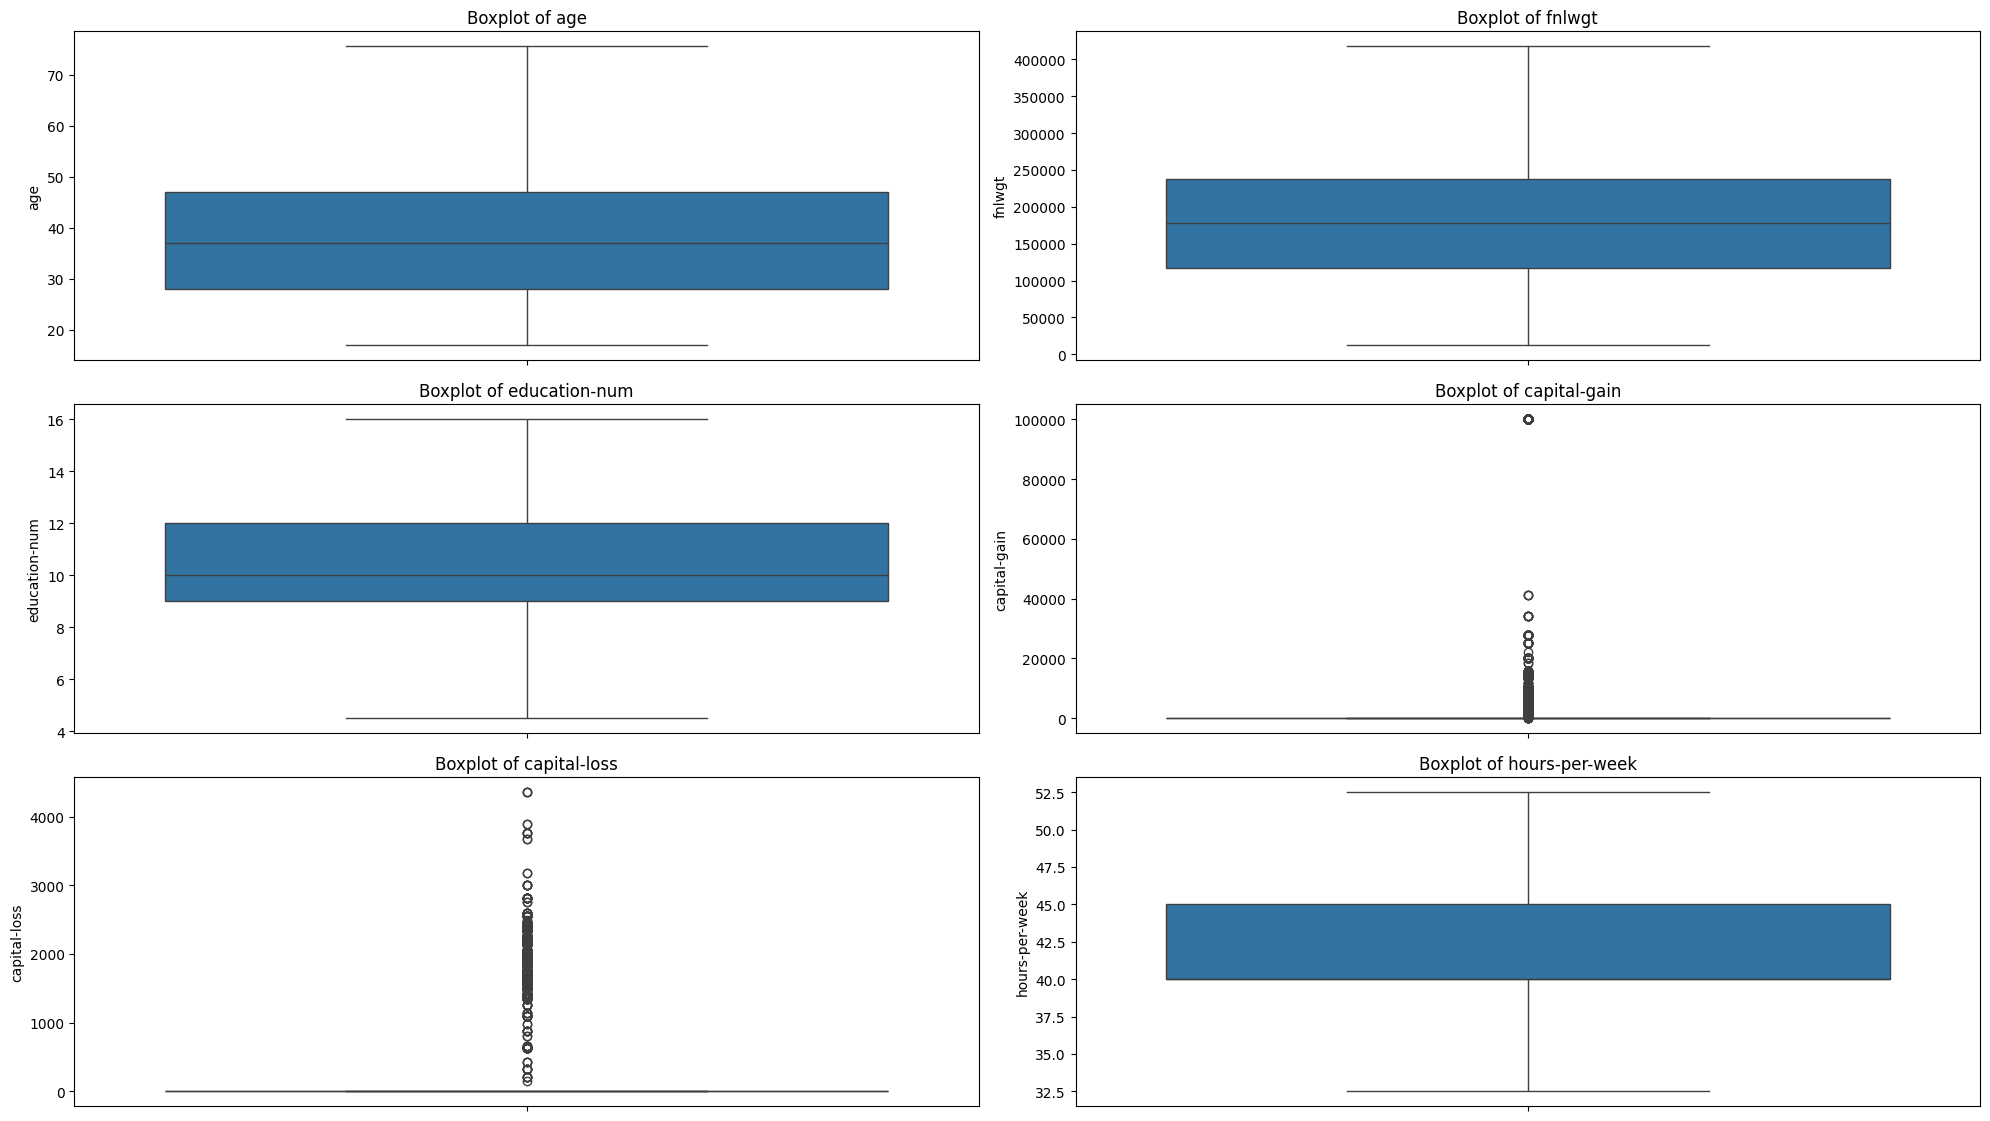

In [21]:
# verify the outlier handling
plt.figure(figsize=(20, 15))

for i, column in enumerate(num_cols):
    plt.subplot(4, 2, i + 1)
    sns.boxplot(adult_df[column])
    plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()


# Data Splitting

In [22]:
X = adult_df.drop('income', axis=1)
y = adult_df['income']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (48826, 14)
Target shape: (48826,)


### One-Hot Encoding for Categorical Features

In [23]:
cat_cols = [col for col in cat_cols if col != 'income'] # income is target
ohe = OneHotEncoder(sparse_output=False)

encoded_features = ohe.fit_transform(X[cat_cols])

encoded_df = pd.DataFrame(encoded_features, columns=ohe.get_feature_names_out(cat_cols), index=X.index)

X = X.drop(columns=cat_cols)
X = pd.concat([X, encoded_df], axis=1)

display(X.head())

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39.0,77516,13.0,2174,0,40.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,50.0,83311,13.0,0,0,32.5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,38.0,215646,9.0,0,0,40.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,53.0,234721,7.0,0,0,40.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,28.0,338409,13.0,0,0,40.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Feature Scaling using StandardScaler

In [25]:

scaler = StandardScaler()

cont_num_cols = ['age', 'fnlwgt', 'hours-per-week', 'education-num', 'capital-gain', 'capital-loss']

cont_num_cols = [col for col in cont_num_cols if col in X.columns]

X_train[cont_num_cols] = scaler.fit_transform(X_train[cont_num_cols])
X_test[cont_num_cols] = scaler.transform(X_test[cont_num_cols])

print(f"X_train shape after scaling: {X_train.shape}")
print(f"X_test shape after scaling: {X_test.shape}")

display(X_train.head())

X_train shape after scaling: (39060, 105)
X_test shape after scaling: (9766, 105)


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
7356,0.408714,0.702866,0.765589,-0.144458,-0.217289,-0.186434,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10136,-0.193759,-0.373410,1.172611,-0.144458,-0.217289,0.643000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
30225,-1.398706,-1.540833,-0.048455,-0.144458,4.037001,-0.849981,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
13100,0.860569,0.916358,-0.048455,-0.144458,-0.217289,-0.186434,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
24215,1.463043,1.389581,-0.455477,-0.144458,-0.217289,1.887151,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [26]:
# Convert target variable to numerical (0 or 1)
y_train = y_train.apply(lambda x: 1 if x.strip() == '>50K' or x.strip() == '>50K.' else 0)
y_test = y_test.apply(lambda x: 1 if x.strip() == '>50K' or x.strip() == '>50K.' else 0)

# Model Building

## TensorFlow Model

In [27]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
# compile the model
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [30]:
import time

In [31]:
start_time_tf = time.perf_counter()
history = model.fit(
    X_train,
    y_train,
    epochs = 20,
    batch_size = 64,
    validation_split = 0.2,
)
end_time_tf = time.perf_counter()

print(f'\nTensorFlow Model Training time: {end_time_tf - start_time_tf:.4f} seconds')

Epoch 1/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8361 - loss: 0.3449 - val_accuracy: 0.8539 - val_loss: 0.3151
Epoch 2/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8547 - loss: 0.3100 - val_accuracy: 0.8579 - val_loss: 0.3123
Epoch 3/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8569 - loss: 0.3069 - val_accuracy: 0.8569 - val_loss: 0.3132
Epoch 4/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8570 - loss: 0.3043 - val_accuracy: 0.8584 - val_loss: 0.3114
Epoch 5/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8596 - loss: 0.3016 - val_accuracy: 0.8566 - val_loss: 0.3121
Epoch 6/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8601 - loss: 0.2997 - val_accuracy: 0.8582 - val_loss: 0.3127
Epoch 7/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8615 - loss: 0.2969 - val_accuracy: 0.8524 - val_loss: 0.3174
Epoch 8/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8610 - loss: 0.2955 - val_accuracy: 0.

In [32]:

loss, accuracy = model.evaluate(X_test, y_test)
print('Accuracy :', accuracy)

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8554 - loss: 0.3226
Accuracy : 0.8554167747497559


## Pytorch Model

In [33]:
# Convert data to tensors
X_train_tensor = torch.FloatTensor(X_train.values)
X_test_tensor = torch.FloatTensor(X_test.values)
y_train_tensor = torch.FloatTensor(y_train.values.reshape(-1, 1))
y_test_tensor = torch.FloatTensor(y_test.values.reshape(-1, 1))


### PyTorch Model Definition

In [34]:
class ANN(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.network(x)

### Model Creation, Loss, and Optimizer

In [35]:
input_dim = X_train_tensor.shape[1]
pytorch_model = ANN(input_dim) # Renamed to pytorch_model to avoid conflict

criterion = nn.BCELoss()    # object of BCELoss
# if this is higher the model is that much wrong

optimizer = optim.Adam(
    pytorch_model.parameters(), # Using pytorch_model here
    lr = 0.001
)

### PyTorch Model Training

In [36]:
start_time = time.perf_counter()
epochs = 50
for epoch in range(epochs):
  # Forward pass
  output = pytorch_model(X_train_tensor) # Using pytorch_model here
  loss = criterion(output, y_train_tensor)

  # Backward and optimize
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if (epoch + 1) % 10 == 0:
    print(f'Epoch {epoch+1}, Loss = {loss.item():.4f}')

end_time = time.perf_counter()

print(f'\nTraining time: {end_time - start_time:.4f} seconds')

Epoch 10, Loss = 0.6420
Epoch 20, Loss = 0.5597
Epoch 30, Loss = 0.4688
Epoch 40, Loss = 0.4111
Epoch 50, Loss = 0.3729

Training time: 3.8994 seconds
